# Image Classification with Deep Learning

## Overview
Image classification assigns a label from a fixed set of categories to an input image. It is the foundational computer vision task solving it well generalizes to detection, segmentation, and more.

**Pipeline**:
```
Raw Image → Preprocessing → Augmentation → Model → Softmax → Class Label
```

---

## CNN Architecture Recap

Output spatial size after convolution:
$$W_{out} = \lfloor \frac{W_{in} - F + 2P}{S} \rfloor + 1$$

where $F$ = filter size, $P$ = padding, $S$ = stride.

**Receptive field** of layer $l$:
$$r_l = r_{l-1} + (k_l - 1) \cdot \prod_{i=1}^{l-1} s_i$$

---

## Key Architectures (Chronological)

| Model | Year | Top-1 ImageNet | Key Innovation |
|-------|------|---------------|----------------|
| LeNet-5 | 1998 | | First practical CNN |
| AlexNet | 2012 | 63.3% | Deep CNN, ReLU, Dropout |
| VGG-16 | 2014 | 74.4% | Deep 3×3 convolutions |
| GoogLeNet | 2014 | 74.8% | Inception module, 1×1 conv |
| ResNet-50 | 2015 | 76.1% | Residual connections |
| DenseNet-121 | 2017 | 74.9% | Dense connections |
| MobileNetV2 | 2018 | 72.0% | Inverted residuals, depth-wise |
| EfficientNet-B0 | 2019 | 77.1% | Compound scaling |
| ViT-B/16 | 2020 | 81.8% | Transformer on patches |
| ConvNeXt-B | 2022 | 83.8% | CNN redesigned like ViT |

**ResNet residual block**:
$$\mathcal{H}(x) = \mathcal{F}(x) + x$$

where $\mathcal{F}(x)$ is the residual mapping (2-3 conv layers). This allows gradients to flow directly through the identity shortcut:
$$\frac{\partial \mathcal{H}}{\partial x} = \frac{\partial \mathcal{F}}{\partial x} + 1$$

**EfficientNet compound scaling**:
$$\text{depth}: d = \alpha^\phi, \quad \text{width}: w = \beta^\phi, \quad \text{resolution}: r = \gamma^\phi$$
subject to $\alpha \cdot \beta^2 \cdot \gamma^2 \approx 2$

---

## Data Augmentation

Augmentation creates artificial training diversity and acts as regularization.

**MixUp**: $$\tilde{x} = \lambda x_i + (1-\lambda)x_j, \quad \tilde{y} = \lambda y_i + (1-\lambda)y_j, \quad \lambda \sim \text{Beta}(\alpha, \alpha)$$

**CutMix**: paste a rectangular patch from image $B$ into image $A$, mixing labels proportional to area.

**Label Smoothing**:
$$y_{smooth} = (1 - \epsilon) y_{hard} + \frac{\epsilon}{K}$$

where $K$ = number of classes, $\epsilon$ = smoothing factor (typically 0.1).

---

## Transfer Learning Strategies

1. **Feature extraction**: freeze all backbone weights, train only the head
2. **Fine-tuning (partial)**: unfreeze top N layers
3. **Full fine-tuning**: unfreeze everything, use small learning rate
4. **Progressive resizing**: start small, increase resolution gradually

**Recommended learning rates**:
- New head: $10^{-3}$ to $10^{-2}$
- Unfrozen backbone: $10^{-5}$ to $10^{-4}$

---

## Grad-CAM

Gradient-weighted Class Activation Mapping visualizes which regions matter.

Weights: $\alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A_{ij}^k}$

Heatmap: $L^c_{Grad-CAM} = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right)$

---

## Evaluation Metrics

**Top-k accuracy**: fraction of samples where correct class is in top-k predictions

$$\text{Top-k Acc} = \frac{1}{N} \sum_{i=1}^N \mathbf{1}[y_i \in \text{top-k}(\hat{p}_i)]$$


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [2]:
# Data augmentation pipelines
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(15),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),  # ImageNet stats
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print('Transforms defined.')

Transforms defined.


In [3]:
# Load CIFAR-10 as example dataset
cifar_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
# testset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)
# train_loader = DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)
# test_loader  = DataLoader(testset,  batch_size=32, shuffle=False, num_workers=2)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print('CIFAR-10 classes:', classes)

CIFAR-10 classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [4]:
# ============================================================
# Transfer Learning with ResNet50
# ============================================================

def build_model(num_classes=10, strategy='feature_extraction'):
    """Build a ResNet50 model with different fine-tuning strategies."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    if strategy == 'feature_extraction':
        # Freeze all layers
        for param in model.parameters():
            param.requires_grad = False

    elif strategy == 'partial_finetune':
        # Freeze early layers, unfreeze layer3, layer4
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer3.parameters():
            param.requires_grad = True
        for param in model.layer4.parameters():
            param.requires_grad = True

    elif strategy == 'full_finetune':
        pass  # All layers remain trainable

    # Replace final classification head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(512, num_classes)
    )

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Strategy: {strategy} | Trainable: {trainable:,} / {total:,}')
    return model

model = build_model(num_classes=10, strategy='partial_finetune')
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/dell/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

  0%|          | 256k/97.8M [00:00<01:00, 1.70MB/s]

  1%|          | 896k/97.8M [00:00<00:25, 3.99MB/s]

  2%|▏         | 1.75M/97.8M [00:00<00:17, 5.92MB/s]

...

 98%|█████████▊| 96.2M/97.8M [00:14<00:00, 4.74MB/s]

 99%|█████████▉| 96.9M/97.8M [00:15<00:00, 5.04MB/s]

100%|█████████▉| 97.5M/97.8M [00:15<00:00, 5.31MB/s]

100%|██████████| 97.8M/97.8M [00:15<00:00, 6.77MB/s]

Strategy: partial_finetune | Trainable: 23,117,322 / 24,562,250


In [5]:
# Training loop with mixed precision
from torch.cuda.amp import GradScaler, autocast

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast():  # Mixed precision
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += images.size(0)

    return total_loss / total, 100. * correct / total


def evaluate(model, loader, criterion, device, top_k=(1, 5)):
    model.eval()
    total_loss, total = 0.0, 0
    correct_k = {k: 0 for k in top_k}

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            total += images.size(0)

            maxk = max(top_k)
            _, pred = outputs.topk(maxk, dim=1, largest=True, sorted=True)
            pred = pred.t()
            correct = pred.eq(labels.view(1, -1).expand_as(pred))
            for k in top_k:
                correct_k[k] += correct[:k].reshape(-1).float().sum().item()

    return total_loss / total, {k: 100. * correct_k[k] / total for k in top_k}


print('Training functions defined. Ready to train!')
print('Usage example (requires dataset):')
print('  optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)')
print('  scaler = GradScaler()')
print('  for epoch in range(num_epochs):')
print('      train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)')

Training functions defined. Ready to train!
Usage example (requires dataset):
  optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
  scaler = GradScaler()
  for epoch in range(num_epochs):
      train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)


MixUp and Label Smoothing implemented.


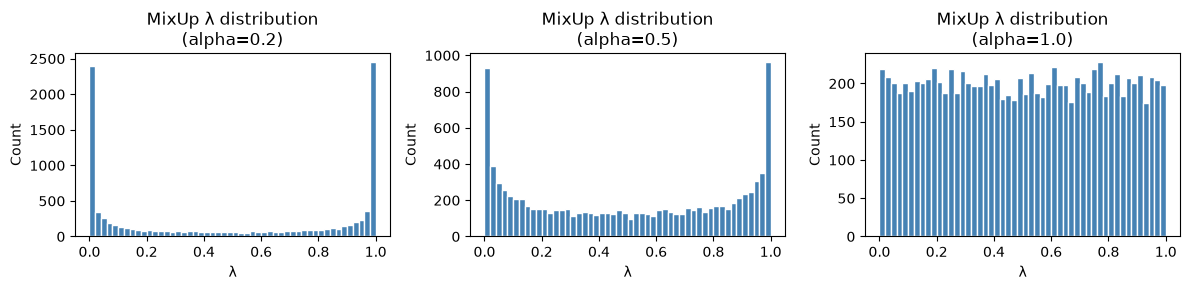

In [6]:
# MixUp augmentation implementation
import torch.nn.functional as F

def mixup_data(x, y, alpha=0.4):
    """Returns mixed inputs, pairs of targets, and lambda."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# Label smoothing cross-entropy
class LabelSmoothingCE(nn.Module):
    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes

    def forward(self, pred, target):
        confidence = 1.0 - self.smoothing
        smooth_val = self.smoothing / (self.num_classes - 1)
        one_hot = torch.zeros_like(pred).scatter_(1, target.unsqueeze(1), 1)
        smooth_one_hot = one_hot * confidence + (1 - one_hot) * smooth_val
        log_prob = F.log_softmax(pred, dim=1)
        loss = -(smooth_one_hot * log_prob).sum(dim=1).mean()
        return loss

print('MixUp and Label Smoothing implemented.')

# Demonstrate lambda distribution for different alpha values
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, alpha in zip(axes, [0.2, 0.5, 1.0]):
    lambdas = np.random.beta(alpha, alpha, 10000)
    ax.hist(lambdas, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'MixUp λ distribution\n(alpha={alpha})')
    ax.set_xlabel('λ'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

In [7]:
# Grad-CAM implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Global average pool gradients: alpha_k^c
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # (B, C, 1, 1)
        # Weighted sum of activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        # Normalize
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.squeeze().cpu().numpy(), class_idx


# Example usage (requires a real image)
print('GradCAM class defined.')
print('Usage:')
print('  grad_cam = GradCAM(model, model.layer4[-1])')
print('  heatmap, predicted_class = grad_cam.generate(input_tensor)')
print('  # Overlay heatmap on original image with cv2.applyColorMap')

GradCAM class defined.
Usage:
  grad_cam = GradCAM(model, model.layer4[-1])
  heatmap, predicted_class = grad_cam.generate(input_tensor)
  # Overlay heatmap on original image with cv2.applyColorMap


In [8]:
# Explore available pretrained models via timm
# pip install timm
try:
    import timm
    # List some popular models
    popular = [
        'resnet50', 'efficientnet_b0', 'vit_base_patch16_224',
        'convnext_base', 'swin_base_patch4_window7_224',
        'deit_base_patch16_224', 'maxvit_base_tf_224'
    ]
    print('Popular models available in timm:')
    for name in popular:
        m = timm.create_model(name, pretrained=False)
        params = sum(p.numel() for p in m.parameters()) / 1e6
        print(f'  {name:<45} | {params:.1f}M params')
except ImportError:
    print('timm not installed. Install with: pip install timm')
    print('timm provides 800+ pretrained models for PyTorch.')

Popular models available in timm:


  resnet50                                      | 25.6M params


  efficientnet_b0                               | 5.3M params


  vit_base_patch16_224                          | 86.6M params


  convnext_base                                 | 88.6M params


  swin_base_patch4_window7_224                  | 87.8M params


  deit_base_patch16_224                         | 86.6M params


  maxvit_base_tf_224                            | 119.5M params


## Additional Learning Resources

### Papers
- [AlexNet ImageNet Classification with Deep CNNs](https://papers.nips.cc/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html) Krizhevsky et al. 2012
- [VGG Very Deep Convolutional Networks](https://arxiv.org/abs/1409.1556) Simonyan & Zisserman 2014
- [ResNet Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) He et al. 2015
- [EfficientNet Rethinking Model Scaling for CNNs](https://arxiv.org/abs/1905.11946) Tan & Le 2019
- [MixUp: Beyond Empirical Risk Minimization](https://arxiv.org/abs/1710.09412) Zhang et al. 2018
- [CutMix: Regularization Strategy by combining patches](https://arxiv.org/abs/1905.04899) Yun et al. 2019
- [Grad-CAM: Visual Explanations from Deep Networks](https://arxiv.org/abs/1610.02391) Selvaraju et al. 2017
- [ConvNeXt: A ConvNet for the 2020s](https://arxiv.org/abs/2201.03545) Liu et al. 2022

### Courses & Tutorials
- [CS231n Stanford](http://cs231n.stanford.edu/) Definitive CNN course
- [Fast.ai Practical Deep Learning](https://course.fast.ai/) Top-down approach
- [PyTorch Transfer Learning Tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

### Libraries
- [timm PyTorch Image Models](https://timm.fast.ai/) 800+ pretrained models
- [Albumentations](https://albumentations.ai/) Fast image augmentation library
- [torchvision](https://pytorch.org/vision/stable/index.html) Official PyTorch vision library
- [torchmetrics](https://torchmetrics.readthedocs.io/) ML metrics for PyTorch

### Benchmarks
- [Papers with Code ImageNet Benchmark](https://paperswithcode.com/sota/image-classification-on-imagenet)
